# SI4006 · Entrega M1 — Fine-tuning con LoRA · **v2**
## Predicción del ritmo de generación de residuos en cocinas de restaurante

**Curso:** Tópicos Especiales y Aplicaciones en IA · Universidad EAFIT
**Módulo 1:** Arquitectura transformer y fine-tuning eficiente

---

### ¿Qué hace este sistema, en una frase?

> Mira el estado de un contenedor de basura de la cocina de un restaurante —cuán lleno está, cómo
> viene llenándose, qué hora y qué día es— y **anticipa cuánta basura va a acumular en la próxima
> hora**, clasificándola como poca (`LOW`), media (`MEDIUM`) o mucha (`HIGH`), para que el personal
> sepa cuándo va a tocar vaciarlo antes de que se desborde.

| | |
|---|---|
| **Dataset** | FIKWaste — 3 cocinas de restaurante reales en Portugal (sensores ultrasónicos, 2019) |
| **Familia** | Encoder-only |
| **Modelo base** | `distilbert-base-uncased` |
| **Tarea** | Clasificación multiclase (`LOW` / `MEDIUM` / `HIGH`) |
| **Métrica principal** | F1-macro |
| **Método de ajuste** | LoRA (PEFT) |
| **Semilla** | 42 |

---

### Qué cambia respecto a la v1, y por qué

La v1 corrió completa y dejó dos diagnósticos que **eran hipótesis, no hechos medidos**. La v2 los
convierte en un experimento.

**Resultados de la v1** (validación, 568 ventanas):

| Modelo | Accuracy | Precision-macro | Recall-macro | F1-macro |
|---|---:|---:|---:|---:|
| Baseline: clase mayoritaria (`LOW`) | 0.6690 | 0.2230 | 0.3333 | 0.2672 |
| Baseline: DistilBERT zero-shot | 0.6690 | 0.2230 | 0.3333 | 0.2672 |
| DistilBERT + LoRA (texto numérico, pesos duros) | 0.4137 | 0.4021 | 0.4434 | **0.3747** |
| HistGradientBoosting tabular | 0.6655 | 0.5021 | 0.4283 | **0.4335** |

**Los dos problemas medidos en la v1:**

1. **Los pesos de clase sobrecorrigieron.** Con inverso de frecuencia (`LOW` 0.484 / `HIGH` 2.879,
   razón ~6:1) el modelo pasó de responder `LOW` a todo, a sobrepredecir minorías: emitió ~198 `LOW`,
   ~218 `MEDIUM` y ~152 `HIGH` cuando la realidad era 380 / 127 / 61. La precisión de `HIGH` se hundió
   a 0.197 — **4 de cada 5 alarmas falsas**.
2. **WordPiece destruye la magnitud numérica.** `57.0` → `['57', '.', '0']`, `-2.4` →
   `['-', '2', '.', '4']`. Nuestras features son *solo* números, así que el modelo tiene que reaprender
   aritmética desde fragmentos de texto. Era la explicación propuesta para que un árbol de decisión le
   ganara — pero **no estaba medida**.

**El experimento de la v2: ablación de 2 factores.**

| | Representación | Pesos de clase |
|---|---|---|
| **v1** (corrida previa) | numérica (`57.0 percent full`) | inverso de frecuencia (~6:1) |
| **Run A** | numérica (`57.0 percent full`) | **raíz del inverso (~2.4:1)** |
| **Run B** | **bucketizada** (`more than half full`) | raíz del inverso (~2.4:1) |

- **A vs v1** aísla el efecto de **los pesos** (misma representación).
- **B vs A** aísla el efecto de **la representación** (mismos pesos). Es la prueba directa de la
  hipótesis 2.

> **Lo que NO tocamos:** el rank de LoRA, las épocas, los cortes de clase y el split se quedan igual
> que en la v1. Cambiar más de un factor a la vez haría imposible atribuir la diferencia, y el
> objetivo aquí no es maximizar el número sino entender de dónde viene.

### ⚠️ Nota metodológica (se mantiene de la v1)

FIKWaste es un dataset de **sensores**, no de texto. Para usar un transformer encoder serializamos cada
ventana horaria a una descripción en inglés. Esta transformación *no crea información nueva*.
Mantenemos el *reality check* contra un modelo de árboles (sección 17) porque para datos tabulares
suele ser la herramienta correcta, y esconderlo sería deshonesto.

## 1 · Setup

Requiere **GPU T4** en Colab: `Entorno de ejecución → Cambiar tipo de entorno → T4 GPU`.
Tiempo estimado: ~12 min (dos entrenamientos de ~2.5 min cada uno).

In [1]:
%pip install -q -U peft datasets accelerate scikit-learn
%pip uninstall -y -q torchao
print("Instalación lista.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.6 MB/s eta 0:00:00
Instalación lista.


In [2]:
import os
import gc
import glob
import io
import random
import zipfile
import warnings

import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42

def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_all_seeds()
device = "cuda" if torch.cuda.is_available() else "cpu"

import transformers, peft
print("transformers:", transformers.__version__, "| peft:", peft.__version__)
print("torch:", torch.__version__, "| device:", device)
if device == "cpu":
    print("\n⚠️  Estás en CPU: el notebook corre, pero muy lento. Activa la GPU T4.")
else:
    print("GPU:", torch.cuda.get_device_name(0))

transformers: 5.13.1 | peft: 0.20.0
torch: 2.11.0+cu128 | device: cuda
GPU: Tesla T4


## 2 · Obtención de los datos crudos

Se descarga **directamente desde OSF**, sin subir archivos a mano. Si ya existe la carpeta local
(al clonar el repo), la usa y se salta la descarga.

**Fuente:** https://osf.io/tyaj6/ · **Licencia:** CC BY 4.0
**Cita:** Pereira, L.; Aguiar, V.; Vasconcelos, F. *FIKWaste: A Waste Generation Dataset from Three
Restaurant Kitchens in Portugal.* Data 2021, 6, 25. https://doi.org/10.3390/data6030025

In [3]:
RAW_DIR = "data/raw/FIKWaste"
OSF_ZIP = "https://files.osf.io/v1/resources/tyaj6/providers/osfstorage/?zip="

def ensure_raw_data(raw_dir=RAW_DIR):
    '''Devuelve la carpeta con los datos crudos; la descarga de OSF si no existe.'''
    if os.path.isdir(raw_dir) and glob.glob(os.path.join(raw_dir, "Kitchen *", "*", "measurements.csv")):
        print(f"Usando datos locales en '{raw_dir}'.")
        return raw_dir

    print("Descargando FIKWaste desde OSF…")
    import requests
    r = requests.get(OSF_ZIP, timeout=180)
    r.raise_for_status()
    os.makedirs(raw_dir, exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(raw_dir)
    print(f"Descargado y extraído en '{raw_dir}'.")
    return raw_dir

RAW_DIR = ensure_raw_data()

def load_raw(raw_dir):
    '''Carga measurements, labels y deployments de las 3 cocinas.'''
    meas, labs = [], []
    for path in sorted(glob.glob(os.path.join(raw_dir, "Kitchen *", "*", "measurements.csv"))):
        parts = path.replace("\\", "/").split("/")
        d = pd.read_csv(path, parse_dates=["timestamp"])
        d["kitchen"], d["bin"] = parts[-3], parts[-2]
        meas.append(d)
    for path in sorted(glob.glob(os.path.join(raw_dir, "Kitchen *", "*", "labels.csv"))):
        parts = path.replace("\\", "/").split("/")
        d = pd.read_csv(path, encoding="utf-8-sig", parse_dates=["timestamp"])   # BOM UTF-8
        d["kitchen"], d["bin"] = parts[-3], parts[-2]
        labs.append(d)
    dep = pd.read_csv(os.path.join(raw_dir, "deployments.csv"),
                      dayfirst=True, parse_dates=["start", "end"])
    return (pd.concat(meas, ignore_index=True),
            pd.concat(labs, ignore_index=True), dep)

measurements, labels, deployments = load_raw(RAW_DIR)
print("\nmeasurements:", measurements.shape, "| labels:", labels.shape,
      "| deployments:", deployments.shape)
display(deployments)

Descargando FIKWaste desde OSF…
Descargado y extraído en 'data/raw/FIKWaste'.

measurements: (86044, 5) | labels: (106, 5) | deployments: (3, 14)


,ID,service,area,capacity,has_glass,glass_volume,has_paper,paper_volume,has_plastic,plastic_volume,has_undifferentiated,undifferentiated_volume,start,end
0,1,Dinner,58.15,50,0,NaN,1,0.08,1,0.08,1,0.08,2019-02-06,2019-03-03
1,2,Dinner,25.52,50,1,0.06,1,0.06,1,0.06,1,0.08,2019-03-12,2019-04-02
2,3,Breakfast and Dinner,35.23,40,1,0.08,1,0.06,1,0.08,1,0.08,2019-04-16,2019-05-15


## 3 · Exploración del dataset crudo

Tres cosas importan para el diseño de la tarea:

1. **Cobertura desigual:** la Cocina 1 muestrea cada minuto; las Cocinas 2 y 3 cada 5 minutos (ahorro
   de batería). Los conteos crudos no son comparables entre cocinas.
2. **La Cocina 1 no tiene contenedor de vidrio** → 11 series cocina×contenedor, no 12.
3. **Los labels de vaciado están incompletos a propósito:** solo se conservaron los eventos que al
   menos 2 de los 3 autores confirmaron.

In [4]:
resumen = (measurements.groupby(["kitchen", "bin"])
           .agg(mediciones=("volume", "size"), inicio=("timestamp", "min"),
                fin=("timestamp", "max"), vol_medio=("volume", "mean")).round(1))
resumen["labels_vaciado"] = labels.groupby(["kitchen", "bin"]).size()
display(resumen)

print("Total mediciones:", len(measurements), "| Total labels:", len(labels))
print("Valores faltantes:", measurements.isna().sum().sum())
print("\nFrecuencia de muestreo mediana por cocina:")
for k, g in measurements.groupby("kitchen"):
    dt = g.sort_values("timestamp").groupby("bin").timestamp.diff().dt.total_seconds()
    print(f"  {k}: {dt.median():.0f} s")

mediciones              inicio  \
kitchen   bin                                                
Kitchen 1 Paper                  19365 2019-02-06 09:59:43   
          Plastic                29246 2019-02-06 09:58:41   
          Undifferentiated       10036 2019-02-06 00:00:38   
Kitchen 2 Glass                   3398 2019-03-12 12:15:33   
          Paper                   3024 2019-03-12 12:16:48   
          Plastic                 3403 2019-03-12 12:16:52   
          Undifferentiated        1456 2019-03-12 12:14:43   
Kitchen 3 Glass                   4313 2019-04-16 19:13:28   
          Paper                   4307 2019-04-16 17:33:57   
          Plastic                 5433 2019-04-16 17:34:02   
          Undifferentiated        2063 2019-04-16 17:34:43   

                                           fin  vol_medio  labels_vaciado  
kitchen   bin                                                              
Kitchen 1 Paper            2019-03-01 17:26:09       46.7              12  
          Plastic          2019-03-03 21:22:23       66.4              12  
          Undifferentiated 2019-03-03 11:28:44       43.5              10  
Kitchen 2 Glass            2019-04-02 17:42:56       48.7               6  
          Paper            2019-04-01 21:57:40       68.1              10  
          Plastic          2019-04-02 01:57:51       75.6               8  
          Undifferentiated 2019-04-02 21:28:16       55.2               5  
Kitchen 3 Glass            2019-05-15 00:55:52       52.5               4  
          Paper            2019-05-10 10:51:47       70.5              11  
          Plastic          2019-05-15 00:55:13       79.0              14  
          Undifferentiated 2019-05-14 16:47:59       72.1              14

Total mediciones: 86044 | Total labels: 106
Valores faltantes: 0

Frecuencia de muestreo mediana por cocina:
  Kitchen 1: 59 s
  Kitchen 2: 289 s
  Kitchen 3: 295 s


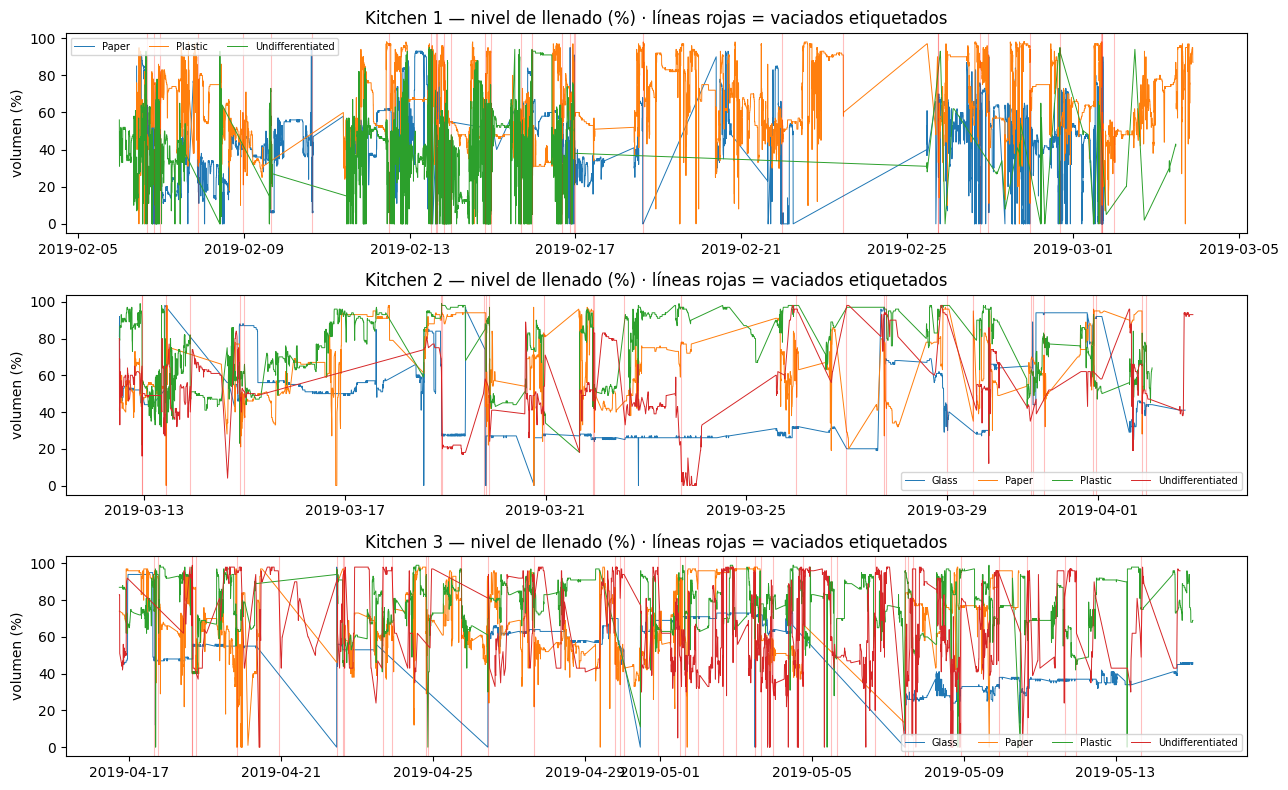

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(13, 8))
for ax, kitchen in zip(axes, ["Kitchen 1", "Kitchen 2", "Kitchen 3"]):
    sub = measurements[measurements.kitchen == kitchen]
    for bin_type, g in sub.groupby("bin"):
        ax.plot(g.timestamp, g.volume, lw=0.7, label=bin_type)
    for t in labels[labels.kitchen == kitchen].timestamp:
        ax.axvline(t, color="red", alpha=0.25, lw=0.8)
    ax.set_title(f"{kitchen} — nivel de llenado (%) · líneas rojas = vaciados etiquetados")
    ax.set_ylabel("volumen (%)")
    ax.legend(fontsize=7, ncol=4)
plt.tight_layout()
plt.show()

## 4 · Preprocesamiento: de señal de sensor a ventanas horarias

Idéntico a la v1 — este bloque no es parte del experimento.

| Feature | Qué es |
|---|---|
| `volume` | nivel de llenado medio en la hora (%) |
| `n_readings` | cuántas lecturas hubo (proxy de calidad del dato) |
| `delta_1h`, `delta_3h` | cambio respecto a 1 y 3 horas antes |
| `mean_3h` | llenado medio de las últimas 3 horas |
| `hours_since_disposal` | horas desde el último vaciado **etiquetado** |
| `hour`, `dayofweek`, `is_weekend` | contexto temporal |

> **Por qué 1 hora:** a 5 min la señal es ruido de sensor; a 1 día quedan 249 filas. La hora deja
> ~3.300 ejemplos, el mínimo razonable para afinar un encoder pequeño.

In [6]:
# --- 4.1 Agregación a ventanas de 1 hora -------------------------------------
frames = []
for (kitchen, bin_type), g in measurements.groupby(["kitchen", "bin"]):
    r = g.set_index("timestamp")["volume"].resample("1h")
    f = pd.DataFrame({"volume": r.mean(), "vol_max": r.max(),
                      "vol_min": r.min(), "n_readings": r.size()}).reset_index()
    f["kitchen"], f["bin"] = kitchen, bin_type
    frames.append(f)

win = (pd.concat(frames, ignore_index=True)
       .sort_values(["kitchen", "bin", "timestamp"]).reset_index(drop=True))

# --- 4.2 Features de historia (solo miran hacia atrás) -----------------------
g = win.groupby(["kitchen", "bin"])
win["delta_1h"] = win["volume"] - g["volume"].shift(1)
win["delta_3h"] = win["volume"] - g["volume"].shift(3)
win["mean_3h"] = g["volume"].transform(lambda s: s.rolling(3, min_periods=1).mean())
win["next_volume"] = g["volume"].shift(-1)
win["next_n_readings"] = g["n_readings"].shift(-1)

# --- 4.3 Horas desde el último vaciado etiquetado ----------------------------
win = win.sort_values("timestamp").reset_index(drop=True)
ev = (labels[["timestamp", "kitchen", "bin"]]
      .rename(columns={"timestamp": "last_disposal"})
      .sort_values("last_disposal").reset_index(drop=True))
win = pd.merge_asof(win, ev, left_on="timestamp", right_on="last_disposal",
                    by=["kitchen", "bin"], direction="backward")
win["hours_since_disposal"] = (win.timestamp - win.last_disposal).dt.total_seconds() / 3600

# --- 4.4 Contexto temporal ---------------------------------------------------
win["hour"] = win.timestamp.dt.hour
win["dayofweek"] = win.timestamp.dt.day_name()
win["is_weekend"] = win.timestamp.dt.dayofweek >= 5
win["date"] = win.timestamp.dt.date
win = win.sort_values(["kitchen", "bin", "timestamp"]).reset_index(drop=True)

print("Ventanas en la rejilla horaria completa:", len(win))
print("Ventanas con al menos una lectura      :", int((win.n_readings > 0).sum()))

Ventanas en la rejilla horaria completa: 6394
Ventanas con al menos una lectura      : 3627


## 5 · Definición de la tarea y del target

**Input:** el estado del contenedor hasta la hora `t`. **Output:** el residuo acumulado entre `t` y `t+1`.

```
incremento = max(0, volume(t+1) − volume(t))
```

Se recorta en 0 porque una bajada de volumen no es "residuo negativo": es un vaciado o el personal
reacomodando la bolsa (documentado en el paper).

| Clase | Incremento | Lectura operativa |
|---|---|---|
| `LOW` | ≤ 1 | el contenedor prácticamente no se movió |
| `MEDIUM` | 1 – 8 | acumulación normal de servicio |
| `HIGH` | > 8 | pico de generación; puede tocar vaciar pronto |

Cortes **fijos e interpretables**, no terciles: al personal le importa el umbral real de llenado.

### 5.1 · Chequeo de leakage

In [7]:
LOW_CUT, HIGH_CUT = 1.0, 8.0
LABEL_ORDER = ["LOW", "MEDIUM", "HIGH"]
label2id = {"LOW": 0, "MEDIUM": 1, "HIGH": 2}
id2label = {v: k for k, v in label2id.items()}

def to_label(inc):
    if inc <= LOW_CUT:
        return "LOW"
    return "MEDIUM" if inc <= HIGH_CUT else "HIGH"

win["increment_next_h"] = (win["next_volume"] - win["volume"]).clip(lower=0)
data = win[(win.n_readings > 0) & (win.next_n_readings > 0)].copy().reset_index(drop=True)
data["label"] = data["increment_next_h"].apply(to_label)

# --- leakage ---
TARGET_COLS = ["next_volume", "next_n_readings", "increment_next_h", "label"]
FEATURE_COLS = ["kitchen", "bin", "hour", "dayofweek", "is_weekend",
                "service", "area_m2", "capacity_seats", "bin_volume_m3",
                "volume", "delta_1h", "delta_3h", "mean_3h", "hours_since_disposal"]
fuga = set(FEATURE_COLS) & set(TARGET_COLS)
assert not fuga, f"LEAKAGE: {fuga}"
print("OK: ninguna columna del target entra como feature.\n")

print("Ventanas utilizables:", len(data))
dist = data.label.value_counts().reindex(LABEL_ORDER)
display(pd.DataFrame({"n": dist, "%": (dist / len(data) * 100).round(1)}))

# --- metadatos de cada cocina ---
BIN_VOL_COL = {"Glass": "glass_volume", "Paper": "paper_volume",
               "Plastic": "plastic_volume", "Undifferentiated": "undifferentiated_volume"}
dep_map = deployments.set_index("ID").to_dict("index")

def kitchen_meta(kitchen, bin_type):
    d = dep_map[int(kitchen.split()[-1])]
    return d["service"], d["area"], d["capacity"], d[BIN_VOL_COL[bin_type]]

meta = [kitchen_meta(k, b) for k, b in zip(data.kitchen, data["bin"])]
data[["service", "area_m2", "capacity_seats", "bin_volume_m3"]] = pd.DataFrame(meta, index=data.index)

OK: ninguna columna del target entra como feature.

Ventanas utilizables: 3306


,n,%
label,,
LOW,2265,68.5
MEDIUM,663,20.1
HIGH,378,11.4


## 6 · Las dos representaciones de texto

Aquí está el corazón del experimento de la v2. Generamos **dos columnas de texto** a partir de
exactamente las mismas features.

### 6.A · Representación numérica (la de la v1)

Escribe los valores tal cual: `"is currently 57.0 percent full"`, `"changed by -2.4 points"`.

### 6.B · Representación bucketizada (nueva)

Convierte cada magnitud en una **expresión léxica ordinal**: `"is more than half full"`,
`"dropped slightly"`. La idea es esquivar el problema medido en la v1: WordPiece parte `57.0` en tres
tokens sin relación numérica entre sí, mientras que `"more than half full"` son palabras que el modelo
ya vio millones de veces durante el preentrenamiento y cuyo orden semántico conoce.

**Los cortes se calibraron sobre la distribución real** (percentiles del propio dataset), no a ojo:

| Feature | Cortes |
|---|---|
| `volume`, `mean_3h` | 25 / 45 / 65 / 85 / 95 → *almost empty … completely full* |
| `delta_1h` | ±1 / ±3 / ±10 → *dropped sharply … rose sharply* |
| `delta_3h` | ±2 / ±5 / ±18 (más ancho: acumula 3 horas) |
| `hours_since_disposal` | 3 / 12 / 30 / 72 h → *less than three hours ago … not in a long time* |
| `hour` | franjas del día en vez del número |

**Lo que se pierde:** resolución. `57.0 %` y `64.9 %` caen en el mismo bucket. Es el precio de la
apuesta, y es justamente lo que el experimento mide: ¿pesa más la precisión numérica que el modelo no
sabe leer, o la semántica ordinal que sí entiende?

In [8]:
BIN_EN = {"Glass": "glass", "Paper": "paper", "Plastic": "plastic",
          "Undifferentiated": "undifferentiated (mostly food) waste"}

# ─────────────────────────── 6.A · texto numérico (v1) ──────────────────────
def row_to_text_num(r):
    weekend = ", a weekend day" if r.is_weekend else ""
    p = [f"Restaurant kitchen {r.kitchen.split()[-1]} serves {str(r.service).lower()}, "
         f"has {r.area_m2:.1f} square meters and seats {int(r.capacity_seats)} guests.",
         f"The monitored container holds {BIN_EN[r['bin']]} and its nominal volume is "
         f"{r.bin_volume_m3:.2f} cubic meters.",
         f"It is {r.dayofweek.lower()}{weekend} at {int(r.hour):02d}:00.",
         f"The container is currently {r.volume:.1f} percent full."]
    p.append(f"Over the last hour the fill level changed by {r.delta_1h:.1f} points."
             if pd.notna(r.delta_1h) else "The change over the last hour is not available.")
    p.append(f"Over the last three hours it changed by {r.delta_3h:.1f} points."
             if pd.notna(r.delta_3h) else "The change over the last three hours is not available.")
    p.append(f"The average fill level in the last three hours was {r.mean_3h:.1f} percent.")
    p.append(f"The container was last emptied {r.hours_since_disposal:.0f} hours ago."
             if pd.notna(r.hours_since_disposal)
             else "There is no record of when the container was last emptied.")
    return " ".join(p)

# ─────────────────────────── 6.B · texto bucketizado ────────────────────────
def nivel(v):
    if v < 25:  return "almost empty"
    if v < 45:  return "about a quarter full"
    if v < 65:  return "about half full"
    if v < 85:  return "more than half full"
    if v < 95:  return "nearly full"
    return "completely full"

def cambio(d, chico, medio, grande):
    if d <= -grande: return "dropped sharply"
    if d <= -medio:  return "dropped"
    if d <= -chico:  return "dropped slightly"
    if d <   chico:  return "stayed flat"
    if d <   medio:  return "rose slightly"
    if d <   grande: return "rose"
    return "rose sharply"

def franja(h):
    if h < 6:   return "late at night"
    if h < 12:  return "in the morning"
    if h < 15:  return "around midday"
    if h < 19:  return "in the afternoon"
    if h < 23:  return "in the evening"
    return "late at night"

def desde_vaciado(h):
    if pd.isna(h): return "There is no record of when the container was last emptied."
    if h < 3:   return "The container was emptied less than three hours ago."
    if h < 12:  return "The container was emptied earlier today."
    if h < 30:  return "The container was emptied about a day ago."
    if h < 72:  return "The container was emptied a few days ago."
    return "The container has not been emptied in a long time."

def tamano(a):
    return "small" if a < 30 else ("medium-sized" if a < 45 else "large")

def row_to_text_bucket(r):
    weekend = ", a weekend day" if r.is_weekend else ""
    p = [f"Restaurant kitchen {r.kitchen.split()[-1]} is a {tamano(r.area_m2)} kitchen that "
         f"serves {str(r.service).lower()}.",
         f"The monitored container holds {BIN_EN[r['bin']]}.",
         f"It is {r.dayofweek.lower()}{weekend} {franja(int(r.hour))}.",
         f"The container is {nivel(r.volume)}."]
    p.append(f"Over the last hour the fill level {cambio(r.delta_1h, 1, 3, 10)}."
             if pd.notna(r.delta_1h) else "The change over the last hour is not available.")
    p.append(f"Over the last three hours it {cambio(r.delta_3h, 2, 5, 18)}."
             if pd.notna(r.delta_3h) else "The change over the last three hours is not available.")
    p.append(f"On average over the last three hours it was {nivel(r.mean_3h)}.")
    p.append(desde_vaciado(r.hours_since_disposal))
    return " ".join(p)

data["text_num"] = data.apply(row_to_text_num, axis=1)
data["text_bucket"] = data.apply(row_to_text_bucket, axis=1)

print("Longitud en palabras:")
display(pd.DataFrame({
    "numérica": data.text_num.str.split().str.len().describe(),
    "bucketizada": data.text_bucket.str.split().str.len().describe(),
}).round(1))

Longitud en palabras:


,numérica,bucketizada
count,3306.0,3306.0
mean,81.3,66.7
std,2.1,3.0
min,77.0,59.0
25%,79.0,65.0
50%,81.0,67.0
75%,82.0,69.0
max,88.0,78.0


In [9]:
# ¿Quedan buckets degenerados (uno solo se lo lleva todo)?
print("Distribución de los buckets generados\n" + "-" * 60)
print("Nivel de llenado (volume):")
print((data.volume.apply(nivel).value_counts(normalize=True) * 100).round(1).to_string())
print("\nCambio en la última hora (delta_1h):")
print((data.delta_1h.dropna().apply(lambda d: cambio(d, 1, 3, 10))
       .value_counts(normalize=True) * 100).round(1).to_string())
print("\nCambio en las últimas 3 horas (delta_3h):")
print((data.delta_3h.dropna().apply(lambda d: cambio(d, 2, 5, 18))
       .value_counts(normalize=True) * 100).round(1).to_string())
print("\nTiempo desde el vaciado:")
print((data.hours_since_disposal.apply(desde_vaciado)
       .value_counts(normalize=True) * 100).round(1).to_string())

Distribución de los buckets generados
------------------------------------------------------------
Nivel de llenado (volume):
volume
about half full         33.9
more than half full     25.2
about a quarter full    17.9
nearly full             14.2
completely full          6.2
almost empty             2.5

Cambio en la última hora (delta_1h):
delta_1h
stayed flat         35.5
rose                14.2
dropped             13.3
dropped slightly     9.8
rose sharply         9.3
dropped sharply      9.1
rose slightly        8.8

Cambio en las últimas 3 horas (delta_3h):
delta_3h
stayed flat         31.5
rose                16.9
dropped             15.2
rose sharply         9.5
dropped slightly     9.3
dropped sharply      9.3
rose slightly        8.4

Tiempo desde el vaciado:
hours_since_disposal
The container was emptied about a day ago.                    27.6
The container was emptied a few days ago.                     23.0
The container has not been emptied in a long time.            1

In [10]:
print("=" * 78)
print("LA MISMA VENTANA, EN LAS DOS REPRESENTACIONES")
print("=" * 78)
completos = data[data.delta_1h.notna() & data.delta_3h.notna()]
for lbl in LABEL_ORDER:
    ej = completos[completos.label == lbl].iloc[0]
    print(f"\n### clase real: {lbl}")
    print(f"[A · numérica  ] {ej.text_num}")
    print(f"[B · bucketizada] {ej.text_bucket}")

LA MISMA VENTANA, EN LAS DOS REPRESENTACIONES

### clase real: LOW
[A · numérica  ] Restaurant kitchen 1 serves dinner, has 58.1 square meters and seats 50 guests. The monitored container holds paper and its nominal volume is 0.08 cubic meters. It is wednesday at 13:00. The container is currently 86.2 percent full. Over the last hour the fill level changed by 16.4 points. Over the last three hours it changed by 39.1 points. The average fill level in the last three hours was 73.0 percent. There is no record of when the container was last emptied.
[B · bucketizada] Restaurant kitchen 1 is a large kitchen that serves dinner. The monitored container holds paper. It is wednesday around midday. The container is nearly full. Over the last hour the fill level rose sharply. Over the last three hours it rose sharply. On average over the last three hours it was more than half full. There is no record of when the container was last emptied.

### clase real: MEDIUM
[A · numérica  ] Restaurant kitch

## 7 · Split train / validation — temporal, no aleatorio

Un split aleatorio **fuga información** en series temporales: las ventanas de las 14:00 y las 15:00 del
mismo día comparten casi todo (`mean_3h`, `delta_3h` se solapan). Si una cae en train y la otra en
validation, el modelo interpola en vez de generalizar y la métrica sale inflada.

Usamos el **primer 80 % de los días de cada cocina** para train y el 20 % final para validation, que es
el escenario de uso real: predecir el futuro, no rellenar el pasado.

In [11]:
train_idx = []
for kitchen, dd in data.groupby("kitchen"):
    dias = sorted(dd.date.unique())
    corte = dias[int(len(dias) * 0.8)]
    train_idx.append(dd.index[dd.date < corte])
    print(f"{kitchen}: {len(dias)} días · corte en {corte} · "
          f"train={int((dd.date < corte).sum())} val={int((dd.date >= corte).sum())}")

train_idx = np.concatenate(train_idx)
data["split"] = np.where(data.index.isin(train_idx), "train", "validation")
train_df = data[data.split == "train"].reset_index(drop=True)
val_df = data[data.split == "validation"].reset_index(drop=True)
y_val = val_df["label"].tolist()

print(f"\nTrain: {len(train_df)} | Validation: {len(val_df)}")
display((pd.crosstab(data.split, data.label, normalize="index")[LABEL_ORDER] * 100).round(1))

os.makedirs("data/processed", exist_ok=True)
COLS_OUT = ["kitchen", "bin", "timestamp", "date", "hour", "dayofweek", "is_weekend",
            "service", "area_m2", "capacity_seats", "bin_volume_m3",
            "volume", "vol_max", "vol_min", "n_readings", "delta_1h", "delta_3h", "mean_3h",
            "hours_since_disposal", "next_volume", "increment_next_h", "label", "split",
            "text_num", "text_bucket"]
data[COLS_OUT].to_csv("data/processed/fikwaste_hourly_windows_v2.csv", index=False)
print("Guardado: data/processed/fikwaste_hourly_windows_v2.csv", data[COLS_OUT].shape)

Kitchen 1: 25 días · corte en 2019-02-27 · train=813 val=183
Kitchen 2: 22 días · corte en 2019-03-29 · train=774 val=146
Kitchen 3: 29 días · corte en 2019-05-09 · train=1151 val=239

Train: 2738 | Validation: 568


label,LOW,MEDIUM,HIGH
split,,,
train,68.8,19.6,11.6
validation,66.9,22.4,10.7


Guardado: data/processed/fikwaste_hourly_windows_v2.csv (3306, 25)


## 8 · Modelo base, tokenizer, y la evidencia del problema numérico

### ¿Por qué encoder-only?

El objetivo de preentrenamiento debe casar con la tarea. Los encoder-only se preentrenan con *masked
language modeling*: atención **bidireccional**, ven toda la secuencia a la vez, y su fuerte es
**clasificar y extraer**. Nuestra entrada es una descripción completa que hay que leer entera antes de
categorizarla. No generamos ni transformamos texto.

### ¿Por qué DistilBERT y no BERT-base?

Destilado de BERT-base: ~40 % menos parámetros (66M vs 110M), ~60 % más rápido, ~97 % del desempeño en
GLUE. Con ~2.700 ejemplos el cuello de botella son los datos, no la capacidad.

### La evidencia que motiva la v2

La celda siguiente **cuantifica** el problema: cuántos tokens gasta cada representación y cómo se
fragmentan los números.

In [12]:
from transformers import AutoTokenizer

BASE_MODEL = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

print("--- Cómo trata WordPiece los números (el problema de la v1) ---")
for term in ["57.0", "8.0", "0.08", "-2.4", "13:00", "64.9"]:
    print(f"  {term!r:9} -> {tokenizer.tokenize(term)}")

print("\n--- Cómo trata las expresiones bucketizadas (la apuesta de la v2) ---")
for term in ["almost empty", "about half full", "more than half full", "nearly full",
             "dropped sharply", "rose slightly", "stayed flat"]:
    print(f"  {term!r:22} -> {tokenizer.tokenize(term)}")

muestra = data.sample(300, random_state=SEED)
tok_num = [len(tokenizer.tokenize(t)) for t in muestra.text_num]
tok_buc = [len(tokenizer.tokenize(t)) for t in muestra.text_bucket]
print(f"\nLongitud en tokens (muestra de 300):")
print(f"  A · numérica   : media {np.mean(tok_num):5.1f}  máx {max(tok_num)}")
print(f"  B · bucketizada: media {np.mean(tok_buc):5.1f}  máx {max(tok_buc)}"
      f"   ({(1 - np.mean(tok_buc) / np.mean(tok_num)) * 100:.0f}% menos)")

MAX_LEN = 192
print(f"\nMAX_LEN = {MAX_LEN} (cubre ambas sin truncar)")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

--- Cómo trata WordPiece los números (el problema de la v1) ---
  '57.0'    -> ['57', '.', '0']
  '8.0'     -> ['8', '.', '0']
  '0.08'    -> ['0', '.', '08']
  '-2.4'    -> ['-', '2', '.', '4']
  '13:00'   -> ['13', ':', '00']
  '64.9'    -> ['64', '.', '9']

--- Cómo trata las expresiones bucketizadas (la apuesta de la v2) ---
  'almost empty'         -> ['almost', 'empty']
  'about half full'      -> ['about', 'half', 'full']
  'more than half full'  -> ['more', 'than', 'half', 'full']
  'nearly full'          -> ['nearly', 'full']
  'dropped sharply'      -> ['dropped', 'sharply']
  'rose slightly'        -> ['rose', 'slightly']
  'stayed flat'          -> ['stayed', 'flat']

Longitud en tokens (muestra de 300):
  A · numérica   : media 105.8  máx 118
  B · bucketizada: media  76.4  máx 91   (28% menos)

MAX_LEN = 192 (cubre ambas sin truncar)


**Lo que hay que mirar en la salida de arriba:** `57.0` y `64.9` se parten en tokens que no comparten
nada — para el modelo no están "cerca", aunque numéricamente disten 8 puntos. En cambio
`about half full` y `more than half full` comparten tokens y son expresiones que DistilBERT vio miles
de veces en el preentrenamiento, con su orden semántico ya codificado.

La representación bucketizada además es **más corta en tokens**, lo que abarata el entrenamiento. Si
además rinde igual o mejor, la decisión es fácil.

## 9 · Baselines

Idénticos a la v1 y se calculan una sola vez, porque no dependen de la representación ni de los pesos.

1. **Clase mayoritaria** — el piso absoluto. Expone el desbalance: responder siempre `LOW` da ~0.67 de
   accuracy y parece decente, pero su F1-macro es ~0.27.
2. **DistilBERT sin fine-tuning (zero-shot)** — el recomendado por la asignación. Usa el objetivo MLM:
   completar `The waste generation level is [MASK].` comparando `low` / `medium` / `high`.

In [13]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

def evaluar(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred),
            "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0)}

clase_mayoritaria = train_df["label"].value_counts().idxmax()
pred_mayoritaria = [clase_mayoritaria] * len(val_df)
baseline_majority = evaluar(y_val, pred_mayoritaria)
print(f"Clase mayoritaria en train: {clase_mayoritaria}")

Clase mayoritaria en train: LOW


In [14]:
from transformers import AutoModelForMaskedLM

mlm = AutoModelForMaskedLM.from_pretrained(BASE_MODEL).to(device).eval()
mask = tokenizer.mask_token
candidatos = {}
for palabra, clase in [("low", "LOW"), ("medium", "MEDIUM"), ("high", "HIGH")]:
    ids = tokenizer(palabra, add_special_tokens=False)["input_ids"]
    assert len(ids) == 1, f"'{palabra}' no es un token único: {ids}"
    candidatos[clase] = ids[0]

@torch.no_grad()
def zero_shot_batch(textos, batch_size=32):
    preds, orden = [], [candidatos[c] for c in LABEL_ORDER]
    for i in range(0, len(textos), batch_size):
        prompts = [f"{t} The waste generation level is {mask}." for t in textos[i:i + batch_size]]
        enc = tokenizer(prompts, return_tensors="pt", padding=True,
                        truncation=True, max_length=MAX_LEN).to(device)
        logits = mlm(**enc).logits
        pos = (enc["input_ids"] == tokenizer.mask_token_id).float().argmax(dim=1)
        elegido = logits[torch.arange(logits.size(0)), pos][:, orden].argmax(dim=1).cpu().numpy()
        preds.extend(LABEL_ORDER[j] for j in elegido)
    return preds

pred_zero = zero_shot_batch(val_df["text_num"].tolist())
baseline_zero = evaluar(y_val, pred_zero)

print("Distribución de lo que predice el zero-shot:",
      pd.Series(pred_zero).value_counts().to_dict())
display(pd.DataFrame([baseline_majority, baseline_zero],
                     index=[f"Majority ({clase_mayoritaria})", "DistilBERT zero-shot"]).round(4))

del mlm
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Distribución de lo que predice el zero-shot: {'LOW': 568}


,accuracy,precision_macro,recall_macro,f1_macro
Majority (LOW),0.669,0.223,0.3333,0.2672
DistilBERT zero-shot,0.669,0.223,0.3333,0.2672


## 10 · Pesos de clase: el factor 1 del experimento

La v1 usó **inverso de frecuencia**: `peso_c = N / (3 · n_c)`. Con 67/20/12 eso da una razón de casi
**6:1** entre `HIGH` y `LOW`, y el resultado medido fue que el modelo **sobrepredijo las minorías**
(emitió ~152 `HIGH` cuando había 61), hundiendo la precisión de `HIGH` a 0.197.

La v2 usa **raíz del inverso de frecuencia**, renormalizada. Es el punto medio estándar entre no
ponderar (colapsa a `LOW`) y ponderar del todo (sobrecorrige): mantiene el empuje hacia las minorías
pero lo reduce a una razón de ~**2.4:1**.

In [15]:
conteo = train_df["label"].map(label2id).value_counts().sort_index()

pesos_v1 = torch.tensor((len(train_df) / (3 * conteo)).values, dtype=torch.float)
raiz = np.sqrt((len(train_df) / (3 * conteo)).values)
pesos_v2 = torch.tensor(raiz / raiz.mean(), dtype=torch.float)   # renormalizados a media 1

comp_pesos = pd.DataFrame({
    "n en train": conteo.values,
    "v1 · inverso": pesos_v1.numpy().round(3),
    "v2 · raíz del inverso": pesos_v2.numpy().round(3),
}, index=[id2label[i] for i in conteo.index])
display(comp_pesos)
print(f"Razón HIGH:LOW  ->  v1 = {pesos_v1[2] / pesos_v1[0]:.2f}:1"
      f"   |   v2 = {pesos_v2[2] / pesos_v2[0]:.2f}:1")

,n en train,v1 · inverso,v2 · raíz del inverso
LOW,1885,0.484,0.565
MEDIUM,536,1.703,1.059
HIGH,317,2.879,1.377


Razón HIGH:LOW  ->  v1 = 5.95:1   |   v2 = 2.44:1


## 11 · Configuración de LoRA y función de entrenamiento

**LoRA se queda exactamente igual que en la v1** — es lo que mantenemos fijo para que la ablación
signifique algo.

| Hiperparámetro | Valor | Por qué |
|---|---|---|
| `r` (rank) | `8` | ~2.700 ejemplos y texto de plantilla fija. `r=8` da capacidad suficiente sin sobreajustar. |
| `lora_alpha` | `16` | Regla estándar `alpha ≈ 2·r`; el factor `alpha/r = 2` mantiene estable la magnitud de la actualización. |
| `lora_dropout` | `0.10` | Dataset pequeño y repetitivo → regularización explícita. |
| `target_modules` | `["q_lin", "v_lin"]` | Proyecciones *query* y *value* de la atención en DistilBERT: es donde se decide *a qué atiende* el modelo, que es lo que cambia entre dominios. |
| `modules_to_save` | `["pre_classifier", "classifier"]` | **Crítico.** La cabeza de 3 clases nace aleatoria; sin marcarla entrenable, LoRA ajustaría el cuerpo contra una cabeza al azar. |

La función `entrenar()` encapsula una corrida completa. Construye un **modelo nuevo cada vez** (si no,
la segunda corrida continuaría desde la primera y la comparación no valdría) y resetea las semillas.

In [16]:
import inspect
from datasets import Dataset
from transformers import (AutoModelForSequenceClassification, DataCollatorWithPadding,
                          TrainingArguments, Trainer)
from peft import LoraConfig, TaskType, get_peft_model

collator = DataCollatorWithPadding(tokenizer=tokenizer)

def to_hf(df, text_col):
    d = Dataset.from_pandas(
        df[[text_col, "label"]].rename(columns={text_col: "text"})
        .assign(labels=df["label"].map(label2id)).drop(columns=["label"]),
        preserve_index=False)
    d = d.map(lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LEN), batched=True)
    return d.remove_columns([c for c in d.column_names
                             if c not in ("input_ids", "attention_mask", "labels")])

def compute_metrics(eval_pred):
    logits, labels_ = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels_, preds),
            "precision_macro": precision_score(labels_, preds, average="macro", zero_division=0),
            "recall_macro": recall_score(labels_, preds, average="macro", zero_division=0),
            "f1_macro": f1_score(labels_, preds, average="macro", zero_division=0)}

def entrenar(text_col, pesos, nombre, seed=SEED, epochs=6, verbose=True):
    '''Una corrida completa de fine-tuning. Devuelve métricas, predicciones e historial.'''
    set_all_seeds(seed)
    train_tok, val_tok = to_hf(train_df, text_col), to_hf(val_df, text_col)

    modelo = AutoModelForSequenceClassification.from_pretrained(
        BASE_MODEL, num_labels=3, id2label=id2label, label2id=label2id)
    modelo = get_peft_model(modelo, LoraConfig(
        task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.10,
        target_modules=["q_lin", "v_lin"],
        modules_to_save=["pre_classifier", "classifier"]))
    if verbose:
        modelo.print_trainable_parameters()

    w = pesos.clone()

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels_ = inputs.pop("labels")
            outputs = model(**inputs)
            loss = torch.nn.functional.cross_entropy(
                outputs.logits, labels_, weight=w.to(outputs.logits.device))
            return (loss, outputs) if return_outputs else loss

    ta = dict(output_dir=f"./out_{nombre}_s{seed}", learning_rate=2e-4,
              per_device_train_batch_size=16, per_device_eval_batch_size=64,
              num_train_epochs=epochs, weight_decay=0.01, warmup_ratio=0.1,
              logging_steps=50, save_total_limit=1, load_best_model_at_end=True,
              metric_for_best_model="f1_macro", greater_is_better=True,
              report_to="none", seed=seed, disable_tqdm=not verbose)
    params = inspect.signature(TrainingArguments.__init__).parameters
    ta["eval_strategy" if "eval_strategy" in params else "evaluation_strategy"] = "epoch"
    ta["save_strategy"] = "epoch"

    tr_kwargs = dict(model=modelo, args=TrainingArguments(**ta),
                     train_dataset=train_tok, eval_dataset=val_tok,
                     data_collator=collator, compute_metrics=compute_metrics)
    tp = inspect.signature(Trainer.__init__).parameters
    tr_kwargs["processing_class" if "processing_class" in tp else "tokenizer"] = tokenizer

    trainer = WeightedTrainer(**tr_kwargs)
    trainer.train()

    out = trainer.predict(val_tok)
    preds = [id2label[int(i)] for i in np.argmax(out.predictions, axis=-1)]
    hist = pd.DataFrame([h for h in trainer.state.log_history if "eval_f1_macro" in h])

    res = {"nombre": nombre, "metrics": evaluar(y_val, preds), "preds": preds,
           "hist": hist, "modelo": modelo}
    del trainer
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()
    return res

print("Función de entrenamiento lista.")

Función de entrenamiento lista.


## 12 · Run A — representación numérica + pesos suaves

Cambia **un solo factor** respecto a la v1: los pesos. Misma representación, mismo LoRA, mismas épocas,
misma semilla. La diferencia A − v1 es atribuible a la ponderación.

In [17]:
run_A = entrenar("text_num", pesos_v2, "A_numerico")
print("\n### Run A · numérico + pesos suaves")
display(pd.DataFrame([run_A["metrics"]], index=["Run A"]).round(4))
display(run_A["hist"][["epoch", "eval_loss", "eval_accuracy", "eval_f1_macro"]].round(4))

Map:   0%|          | 0/2738 [00:00<?, ? examples/s]

Map:   0%|          | 0/568 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.0936


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.022749,1.036021,0.669014,0.223005,0.333333,0.267229
2,0.985207,0.987467,0.669014,0.223005,0.333333,0.267229
3,0.990918,0.979184,0.676056,0.502570,0.359779,0.317975
4,0.965305,0.986303,0.658451,0.332451,0.369356,0.331908
5,0.991673,0.968208,0.649648,0.455599,0.389435,0.385859
6,0.971744,0.967168,0.647887,0.377952,0.375015,0.344621



### Run A · numérico + pesos suaves


,accuracy,precision_macro,recall_macro,f1_macro
Run A,0.6496,0.4556,0.3894,0.3859


,epoch,eval_loss,eval_accuracy,eval_f1_macro
0,1.0,1.0360,0.6690,0.2672
1,2.0,0.9875,0.6690,0.2672
2,3.0,0.9792,0.6761,0.3180
3,4.0,0.9863,0.6585,0.3319
4,5.0,0.9682,0.6496,0.3859
5,6.0,0.9672,0.6479,0.3446


## 13 · Run B — representación bucketizada + pesos suaves

Cambia **un solo factor** respecto al Run A: la representación. La diferencia B − A es atribuible a
bucketizar los números, que es la hipótesis central de la v2.

In [18]:
run_B = entrenar("text_bucket", pesos_v2, "B_bucket")
print("\n### Run B · bucketizado + pesos suaves")
display(pd.DataFrame([run_B["metrics"]], index=["Run B"]).round(4))
display(run_B["hist"][["epoch", "eval_loss", "eval_accuracy", "eval_f1_macro"]].round(4))

Map:   0%|          | 0/2738 [00:00<?, ? examples/s]

Map:   0%|          | 0/568 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.0936


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.015124,0.977478,0.669014,0.223005,0.333333,0.267229
2,0.947563,0.931835,0.654930,0.359944,0.436411,0.392703
3,0.917864,0.899178,0.660211,0.510741,0.478143,0.427924
4,0.893265,0.896950,0.649648,0.461650,0.474628,0.425672
5,0.904507,0.883131,0.647887,0.505882,0.505641,0.503565
6,0.896903,0.884079,0.656690,0.511777,0.505004,0.485090



### Run B · bucketizado + pesos suaves


,accuracy,precision_macro,recall_macro,f1_macro
Run B,0.6479,0.5059,0.5056,0.5036


,epoch,eval_loss,eval_accuracy,eval_f1_macro
0,1.0,0.9775,0.6690,0.2672
1,2.0,0.9318,0.6549,0.3927
2,3.0,0.8992,0.6602,0.4279
3,4.0,0.8970,0.6496,0.4257
4,5.0,0.8831,0.6479,0.5036
5,6.0,0.8841,0.6567,0.4851


## 14 · Reality check tabular

`HistGradientBoosting` sobre **las mismas features sin pasar por texto**, mismo split, misma métrica.
No es un baseline exigido: es la comprobación de honestidad que ya traíamos de la v1.

In [19]:
from sklearn.ensemble import HistGradientBoostingClassifier

NUM_FEATS = ["volume", "delta_1h", "delta_3h", "mean_3h", "hours_since_disposal",
             "hour", "area_m2", "capacity_seats", "bin_volume_m3", "n_readings"]
BIN_IDS = {b: i for i, b in enumerate(sorted(data["bin"].unique()))}

def matriz(df):
    X = df[NUM_FEATS].astype(float).copy()
    X["kitchen_id"] = df.kitchen.str[-1].astype(int)
    X["bin_id"] = df["bin"].map(BIN_IDS)
    X["dow_id"] = pd.to_datetime(df.timestamp).dt.dayofweek
    return X

gb = HistGradientBoostingClassifier(random_state=SEED, max_iter=200)
gb.fit(matriz(train_df), train_df.label.map(label2id))
pred_gb = [id2label[i] for i in gb.predict(matriz(val_df))]
metrics_gb = evaluar(y_val, pred_gb)
display(pd.DataFrame([metrics_gb], index=["HistGradientBoosting tabular"]).round(4))

,accuracy,precision_macro,recall_macro,f1_macro
HistGradientBoosting tabular,0.6655,0.5021,0.4283,0.4335


## 15 · Tabla comparativa: v1 vs Run A vs Run B

La tabla que responde el experimento. Los números de la v1 vienen de la corrida anterior
(mismo split, mismo código de preprocesamiento, misma semilla) y se citan como referencia.

In [20]:
# Resultados de la corrida v1 (documentados, no recalculados aquí)
V1_LORA = {"accuracy": 0.4137, "precision_macro": 0.4021,
           "recall_macro": 0.4434, "f1_macro": 0.3747}

tabla = pd.DataFrame(
    [baseline_majority, baseline_zero, V1_LORA,
     run_A["metrics"], run_B["metrics"], metrics_gb],
    index=[f"Baseline: clase mayoritaria ({clase_mayoritaria})",
           "Baseline: DistilBERT zero-shot",
           "v1 · numérico + pesos duros (6:1)",
           "Run A · numérico + pesos suaves (2.4:1)",
           "Run B · bucketizado + pesos suaves (2.4:1)",
           "[referencia] HistGradientBoosting tabular"]).round(4)

print("=" * 84)
print("TABLA COMPARATIVA — validación (últimos ~20% de días de cada cocina, 568 ventanas)")
print("=" * 84)
display(tabla)

fA, fB, fV1 = run_A["metrics"]["f1_macro"], run_B["metrics"]["f1_macro"], V1_LORA["f1_macro"]
print("\n--- Efectos aislados (F1-macro) ---")
print(f"  Efecto de los PESOS         (A − v1): {fA - fV1:+.4f}")
print(f"  Efecto de la REPRESENTACIÓN (B − A) : {fB - fA:+.4f}")
print(f"  Mejor corrida v2 vs baselines       : {max(fA, fB) - baseline_zero['f1_macro']:+.4f}")
print(f"  Mejor corrida v2 vs árboles         : {max(fA, fB) - metrics_gb['f1_macro']:+.4f}")

print("\n--- Accuracy (para ver el intercambio con F1-macro) ---")
for n, m in [("v1", V1_LORA), ("Run A", run_A["metrics"]), ("Run B", run_B["metrics"])]:
    print(f"  {n:6}: accuracy {m['accuracy']:.4f}  |  f1_macro {m['f1_macro']:.4f}")

TABLA COMPARATIVA — validación (últimos ~20% de días de cada cocina, 568 ventanas)


,accuracy,precision_macro,recall_macro,f1_macro
Baseline: clase mayoritaria (LOW),0.6690,0.2230,0.3333,0.2672
Baseline: DistilBERT zero-shot,0.6690,0.2230,0.3333,0.2672
v1 · numérico + pesos duros (6:1),0.4137,0.4021,0.4434,0.3747
Run A · numérico + pesos suaves (2.4:1),0.6496,0.4556,0.3894,0.3859
Run B · bucketizado + pesos suaves (2.4:1),0.6479,0.5059,0.5056,0.5036
[referencia] HistGradientBoosting tabular,0.6655,0.5021,0.4283,0.4335



--- Efectos aislados (F1-macro) ---
  Efecto de los PESOS         (A − v1): +0.0112
  Efecto de la REPRESENTACIÓN (B − A) : +0.1177
  Mejor corrida v2 vs baselines       : +0.2363
  Mejor corrida v2 vs árboles         : +0.0701

--- Accuracy (para ver el intercambio con F1-macro) ---
  v1    : accuracy 0.4137  |  f1_macro 0.3747
  Run A : accuracy 0.6496  |  f1_macro 0.3859
  Run B : accuracy 0.6479  |  f1_macro 0.5036


Mejor corrida de la v2 por F1-macro: B_bucket

=== Run A · numérico ===
              precision    recall  f1-score   support

         LOW      0.692     0.911     0.786       380
      MEDIUM      0.341     0.110     0.167       127
        HIGH      0.333     0.148     0.205        61

    accuracy                          0.650       568
   macro avg      0.456     0.389     0.386       568
weighted avg      0.575     0.650     0.585       568

=== Run B · bucketizado ===
              precision    recall  f1-score   support

         LOW      0.760     0.800     0.779       380
      MEDIUM      0.390     0.307     0.344       127
        HIGH      0.368     0.410     0.388        61

    accuracy                          0.648       568
   macro avg      0.506     0.506     0.504       568
weighted avg      0.635     0.648     0.640       568



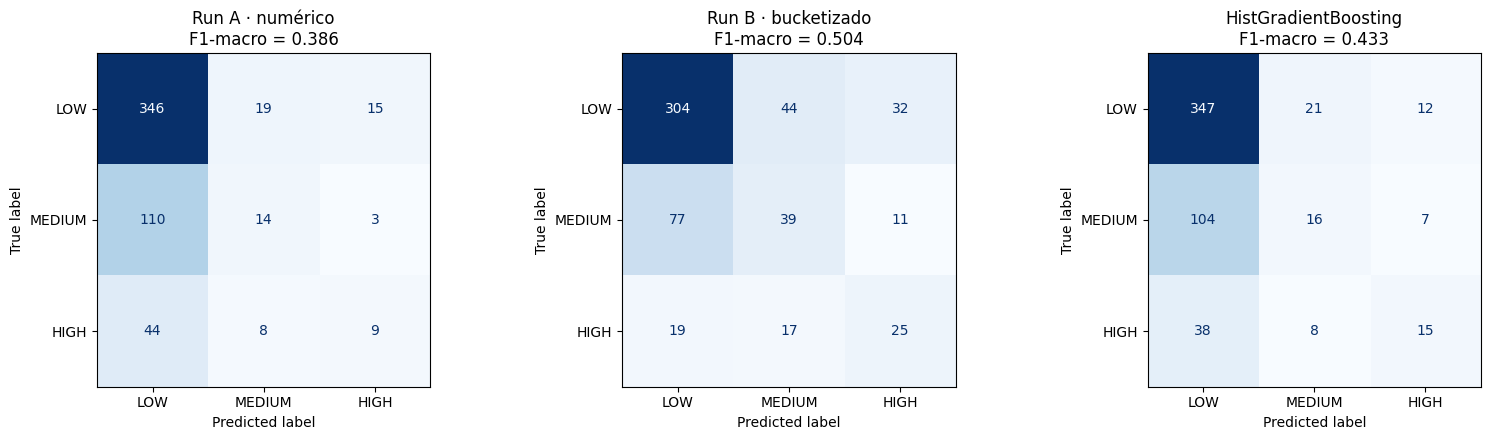

In [21]:
mejor = run_B if fB >= fA else run_A
pred_mejor = mejor["preds"]
print(f"Mejor corrida de la v2 por F1-macro: {mejor['nombre']}\n")

print("=== Run A · numérico ===")
print(classification_report(y_val, run_A["preds"], labels=LABEL_ORDER, zero_division=0, digits=3))
print("=== Run B · bucketizado ===")
print(classification_report(y_val, run_B["preds"], labels=LABEL_ORDER, zero_division=0, digits=3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nombre, preds) in zip(axes, [("Run A · numérico", run_A["preds"]),
                                      ("Run B · bucketizado", run_B["preds"]),
                                      ("HistGradientBoosting", pred_gb)]):
    cm = confusion_matrix(y_val, preds, labels=LABEL_ORDER)
    ConfusionMatrixDisplay(cm, display_labels=LABEL_ORDER).plot(
        ax=ax, values_format="d", cmap="Blues", colorbar=False)
    ax.set_title(f"{nombre}\nF1-macro = {f1_score(y_val, preds, average='macro', zero_division=0):.3f}")
plt.tight_layout()
plt.show()

In [22]:
# ¿Se corrigió la sobrepredicción de minorías que medimos en la v1?
real = pd.Series(y_val).value_counts().reindex(LABEL_ORDER)
emitidas = pd.DataFrame({
    "realidad": real,
    "v1 (medido)": [198, 218, 152],          # reconstruido del reporte de la v1
    "Run A": pd.Series(run_A["preds"]).value_counts().reindex(LABEL_ORDER),
    "Run B": pd.Series(run_B["preds"]).value_counts().reindex(LABEL_ORDER),
})
print("Número de predicciones emitidas por clase:")
display(emitidas)
print("\nRazón emitidas/reales (1.0 = calibrado):")
display((emitidas.div(emitidas["realidad"], axis=0)).round(2))

Número de predicciones emitidas por clase:


,realidad,v1 (medido),Run A,Run B
LOW,380,198,500,400
MEDIUM,127,218,41,100
HIGH,61,152,27,68



Razón emitidas/reales (1.0 = calibrado):


,realidad,v1 (medido),Run A,Run B
LOW,1.0,0.52,1.32,1.05
MEDIUM,1.0,1.72,0.32,0.79
HIGH,1.0,2.49,0.44,1.11


## 16 · Ejemplos cualitativos (entrada → salida)

Al menos 3, con la mejor corrida de la v2. Los errores dicen más que los aciertos.

In [23]:
TEXT_COL = "text_bucket" if mejor["nombre"].startswith("B") else "text_num"
ejemplos = val_df.copy()
ejemplos["prediccion"] = pred_mejor
ejemplos["correcto"] = ejemplos.label == ejemplos.prediccion

def mostrar(df, titulo, n=3):
    print("\n" + "=" * 78 + f"\n{titulo}\n" + "=" * 78)
    for _, r in df.head(n).iterrows():
        print(f"\nENTRADA : {r[TEXT_COL]}")
        print(f"REAL    : {r.label}   ->   PREDICHO: {r.prediccion}   "
              f"{'✓' if r.correcto else '✗'}")
        print(f"(incremento real en la hora siguiente = {r.increment_next_h:.2f} puntos)")

for lbl in LABEL_ORDER:
    sub = ejemplos[(ejemplos.label == lbl) & ejemplos.correcto]
    if not sub.empty:
        mostrar(sub, f"ACIERTO — clase real {lbl}", n=1)

mostrar(ejemplos[~ejemplos.correcto], "ERRORES DEL MODELO", n=3)


ACIERTO — clase real LOW

ENTRADA : Restaurant kitchen 1 is a large kitchen that serves dinner. The monitored container holds paper. It is wednesday late at night. The container is about half full. Over the last hour the fill level dropped. Over the last three hours it dropped. On average over the last three hours it was about half full. The container was emptied earlier today.
REAL    : LOW   ->   PREDICHO: LOW   ✓
(incremento real en la hora siguiente = 0.00 puntos)

ACIERTO — clase real MEDIUM

ENTRADA : Restaurant kitchen 1 is a large kitchen that serves dinner. The monitored container holds paper. It is wednesday in the afternoon. The container is about a quarter full. Over the last hour the fill level rose. Over the last three hours it stayed flat. On average over the last three hours it was about a quarter full. The container was emptied about a day ago.
REAL    : MEDIUM   ->   PREDICHO: MEDIUM   ✓
(incremento real en la hora siguiente = 5.16 puntos)

ACIERTO — clase real HIGH


## 17 · (Opcional) Estabilidad: varias semillas

En la v1 el F1-macro osciló entre épocas (0.3413 → 0.2808 → 0.3619 → 0.3747) con una pérdida que
apenas bajó, así que **un número suelto no es de fiar**. Este bloque repite la mejor configuración con
3 semillas y reporta media ± desviación.

Cuesta ~5 min extra. Si vas justo de tiempo, déjalo en `False` y repórtalo como trabajo pendiente.

In [27]:
RUN_SEEDS = True        # ejecutado: resultados en la sección 20, punto 4

if RUN_SEEDS:
    col_mejor = "text_bucket" if mejor["nombre"].startswith("B") else "text_num"
    filas = []
    for s in [42, 202, 1337]:
        r = entrenar(col_mejor, pesos_v2, f"seed{s}", seed=s, verbose=False)
        filas.append({"seed": s, **r["metrics"]})
        print(f"  seed {s}: f1_macro = {r['metrics']['f1_macro']:.4f}")
    seeds_df = pd.DataFrame(filas).set_index("seed")
    display(seeds_df.round(4))
    print("\nMedia ± desviación:")
    for c in ["accuracy", "f1_macro"]:
        print(f"  {c:9}: {seeds_df[c].mean():.4f} ± {seeds_df[c].std():.4f}")
else:
    print("Bloque de semillas desactivado (RUN_SEEDS = False).")

Map:   0%|          | 0/2738 [00:00<?, ? examples/s]

Map:   0%|          | 0/568 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


{'loss': '1.045', 'grad_norm': '1.212', 'learning_rate': '9.423e-05', 'epoch': '0.2907'}
{'loss': '1.038', 'grad_norm': '1.9', 'learning_rate': '0.0001904', 'epoch': '0.5814'}
{'loss': '1.015', 'grad_norm': '1.636', 'learning_rate': '0.0001903', 'epoch': '0.8721'}
{'eval_loss': '0.9775', 'eval_accuracy': '0.669', 'eval_precision_macro': '0.223', 'eval_recall_macro': '0.3333', 'eval_f1_macro': '0.2672', 'eval_runtime': '1.812', 'eval_samples_per_second': '313.5', 'eval_steps_per_second': '4.968', 'epoch': '1'}
{'loss': '0.95', 'grad_norm': '1.33', 'learning_rate': '0.0001795', 'epoch': '1.163'}
{'loss': '0.9536', 'grad_norm': '2.69', 'learning_rate': '0.0001688', 'epoch': '1.453'}
{'loss': '0.9476', 'grad_norm': '2.269', 'learning_rate': '0.000158', 'epoch': '1.744'}
{'eval_loss': '0.9318', 'eval_accuracy': '0.6549', 'eval_precision_macro': '0.3599', 'eval_recall_macro': '0.4364', 'eval_f1_macro': '0.3927', 'eval_runtime': '1.615', 'eval_samples_per_second': '351.8', 'eval_steps_per_sec

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


{'loss': '1.049', 'grad_norm': '0.9198', 'learning_rate': '9.423e-05', 'epoch': '0.2907'}
{'loss': '1.004', 'grad_norm': '2.474', 'learning_rate': '0.0001904', 'epoch': '0.5814'}
{'loss': '1.008', 'grad_norm': '2.166', 'learning_rate': '0.0001903', 'epoch': '0.8721'}
{'eval_loss': '1.004', 'eval_accuracy': '0.669', 'eval_precision_macro': '0.223', 'eval_recall_macro': '0.3333', 'eval_f1_macro': '0.2672', 'eval_runtime': '1.642', 'eval_samples_per_second': '345.8', 'eval_steps_per_second': '5.48', 'epoch': '1'}
{'loss': '1.008', 'grad_norm': '1.617', 'learning_rate': '0.0001795', 'epoch': '1.163'}
{'loss': '0.9579', 'grad_norm': '1.076', 'learning_rate': '0.0001688', 'epoch': '1.453'}
{'loss': '0.9712', 'grad_norm': '1.138', 'learning_rate': '0.000158', 'epoch': '1.744'}
{'eval_loss': '0.934', 'eval_accuracy': '0.6391', 'eval_precision_macro': '0.5112', 'eval_recall_macro': '0.467', 'eval_f1_macro': '0.3993', 'eval_runtime': '1.649', 'eval_samples_per_second': '344.5', 'eval_steps_per_s

,accuracy,precision_macro,recall_macro,f1_macro
seed,,,,
42,0.6479,0.5059,0.5056,0.5036
202,0.6514,0.4898,0.4786,0.4498
1337,0.6532,0.5014,0.4998,0.4820



Media ± desviación:
  accuracy : 0.6508 ± 0.0027
  f1_macro : 0.4784 ± 0.0271


## 18 · Guardar el adaptador LoRA

Solo las matrices de bajo rango y la cabeza de clasificación: unos pocos MB.

In [25]:
ADAPTER_DIR = f"./distilbert-lora-fikwaste-v2-{mejor['nombre']}"
mejor["modelo"].save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
total_mb = sum(os.path.getsize(os.path.join(ADAPTER_DIR, f))
               for f in os.listdir(ADAPTER_DIR)) / 1e6
print(f"Adaptador guardado en {ADAPTER_DIR} ({total_mb:.1f} MB)")
print(os.listdir(ADAPTER_DIR))

Adaptador guardado en ./distilbert-lora-fikwaste-v2-B_bucket (3.7 MB)
['tokenizer.json', 'README.md', 'tokenizer_config.json', 'adapter_config.json', 'adapter_model.safetensors']


## 19 · Resumen de resultados

Lo que se copia al README. **No escribas números a mano: sal de aquí.**

In [26]:
print("=" * 84)
print("RESUMEN M1 v2 — Ablación representación × pesos de clase sobre FIKWaste")
print("=" * 84)
print(f"Dataset          : FIKWaste (3 cocinas, Portugal, 2019) · CC BY 4.0")
print(f"Ventanas         : {len(data)}  (train {len(train_df)} / validation {len(val_df)})")
print(f"Split            : temporal por día (primer 80% de días -> train)")
print(f"Modelo base      : {BASE_MODEL} (encoder-only, 66M parámetros)")
print(f"LoRA             : r=8, alpha=16, dropout=0.10, target=['q_lin','v_lin']")
print(f"Métrica principal: F1-macro")
print()
display(tabla)

print("\n--- EFECTOS AISLADOS (F1-macro) ---")
print(f"  Pesos duros -> suaves      (A − v1): {fA - fV1:+.4f}")
print(f"  Numérico -> bucketizado    (B − A) : {fB - fA:+.4f}")
print()
print(f"  Mejor v2 ({mejor['nombre']}) vs baseline zero-shot: "
      f"{max(fA, fB) - baseline_zero['f1_macro']:+.4f}")
print(f"  Mejor v2 ({mejor['nombre']}) vs árboles tabulares : "
      f"{max(fA, fB) - metrics_gb['f1_macro']:+.4f}")

peor = min(LABEL_ORDER, key=lambda c: f1_score(
    [1 if y == c else 0 for y in y_val],
    [1 if p == c else 0 for p in pred_mejor], zero_division=0))
print(f"\n  Clase con peor F1 en la mejor corrida: {peor}")

print("\n--- LECTURA AUTOMÁTICA (verifícala antes de copiarla) ---")
if fB > fA:
    print(f"  · Bucketizar los números AYUDÓ ({fB - fA:+.4f}): apoya la hipótesis de que WordPiece")
    print("    destruye la magnitud numérica y que la semántica ordinal la recupera en parte.")
elif fB < fA:
    print(f"  · Bucketizar los números NO ayudó ({fB - fA:+.4f}): la pérdida de resolución pesa más")
    print("    que la ganancia semántica. La hipótesis de la v1 queda refutada en esta forma.")
else:
    print("  · Bucketizar dio exactamente lo mismo: sin evidencia en ninguna dirección.")

if fA > fV1:
    print(f"  · Suavizar los pesos AYUDÓ ({fA - fV1:+.4f}): la razón 6:1 de la v1 sobrecorregía.")
else:
    print(f"  · Suavizar los pesos NO ayudó en F1-macro ({fA - fV1:+.4f}); revisar la accuracy,")
    print("    que es donde se esperaba la mejora.")

RESUMEN M1 v2 — Ablación representación × pesos de clase sobre FIKWaste
Dataset          : FIKWaste (3 cocinas, Portugal, 2019) · CC BY 4.0
Ventanas         : 3306  (train 2738 / validation 568)
Split            : temporal por día (primer 80% de días -> train)
Modelo base      : distilbert-base-uncased (encoder-only, 66M parámetros)
LoRA             : r=8, alpha=16, dropout=0.10, target=['q_lin','v_lin']
Métrica principal: F1-macro



,accuracy,precision_macro,recall_macro,f1_macro
Baseline: clase mayoritaria (LOW),0.6690,0.2230,0.3333,0.2672
Baseline: DistilBERT zero-shot,0.6690,0.2230,0.3333,0.2672
v1 · numérico + pesos duros (6:1),0.4137,0.4021,0.4434,0.3747
Run A · numérico + pesos suaves (2.4:1),0.6496,0.4556,0.3894,0.3859
Run B · bucketizado + pesos suaves (2.4:1),0.6479,0.5059,0.5056,0.5036
[referencia] HistGradientBoosting tabular,0.6655,0.5021,0.4283,0.4335



--- EFECTOS AISLADOS (F1-macro) ---
  Pesos duros -> suaves      (A − v1): +0.0112
  Numérico -> bucketizado    (B − A) : +0.1177

  Mejor v2 (B_bucket) vs baseline zero-shot: +0.2363
  Mejor v2 (B_bucket) vs árboles tabulares : +0.0701

  Clase con peor F1 en la mejor corrida: MEDIUM

--- LECTURA AUTOMÁTICA (verifícala antes de copiarla) ---
  · Bucketizar los números AYUDÓ (+0.1177): apoya la hipótesis de que WordPiece
    destruye la magnitud numérica y que la semántica ordinal la recupera en parte.
  · Suavizar los pesos AYUDÓ (+0.0112): la razón 6:1 de la v1 sobrecorregía.


## 20 · Conclusiones

*Ejecución del 13 de agosto de 2026 en Colab (Tesla T4, `transformers` 5.13.1, `peft` 0.20.0).
Todos los números salen de las celdas de arriba.*

### Resultado

| Modelo | Accuracy | Precision-macro | Recall-macro | **F1-macro** |
|---|---:|---:|---:|---:|
| Baseline: clase mayoritaria (`LOW`) | 0.6690 | 0.2230 | 0.3333 | 0.2672 |
| Baseline: DistilBERT zero-shot | 0.6690 | 0.2230 | 0.3333 | 0.2672 |
| v1 · numérico + pesos duros (6:1) | 0.4137 | 0.4021 | 0.4434 | 0.3747 |
| Run A · numérico + pesos suaves (2.4:1) | 0.6496 | 0.4556 | 0.3894 | 0.3859 |
| **Run B · bucketizado + pesos suaves (2.4:1)** | 0.6479 | 0.5059 | 0.5056 | **0.5036** |
| **Run B · promedio sobre 3 semillas** ⭐ | **0.6508 ± 0.0027** | — | — | **0.4784 ± 0.0271** |
| *[referencia]* HistGradientBoosting tabular | 0.6655 | 0.5021 | 0.4283 | 0.4335 |

**El número que reportamos como resultado del proyecto es `F1-macro = 0.478 ± 0.027`**, no el 0.5036
de la semilla 42. Ver la sección 4.

**Efectos aislados (F1-macro):**

| Factor | Comparación | Δ |
|---|---|---:|
| Pesos de clase (6:1 → 2.4:1) | A − v1 | **+0.0112** |
| Representación (numérica → bucketizada) | B̄ − A | **+0.0925** |
| Mejor configuración vs baselines | B̄ − zero-shot | **+0.2112** |
| Mejor configuración vs árboles | B̄ − HistGB | **+0.0449** |

---

### 1 · ¿Qué factor pesó más? La representación, por ocho veces

**El efecto de bucketizar (+0.0925) es ocho veces mayor que el de suavizar los pesos (+0.0112).** Y
aguanta: incluso con la **peor** de las tres semillas el efecto de la representación sigue siendo
+0.0639, más de cinco veces el de los pesos. Esta conclusión no depende de la suerte.

Son además dos efectos de naturaleza distinta.

**Los pesos casi no movieron el F1-macro, pero arreglaron la accuracy**, que pasó de 0.4137 a 0.6496
(+0.236). Lo que hicieron fue **dejar de destrozar la clase mayoritaria** sin ganar nada real en las
minorías. De hecho **sobrecorrigieron hacia el otro lado**: el Run A emitió 500 `LOW`, 41 `MEDIUM` y
27 `HIGH` cuando la realidad era 380 / 127 / 61 — razones de 1.32 / 0.32 / 0.44. Casi volvió a
colapsar a `LOW`: el recall de `MEDIUM` se hundió a 0.110 y el de `HIGH` a 0.148.

Con la representación numérica **no hay un valor de pesos que funcione**: con 6:1 sobrepredice
minorías, con 2.4:1 las ignora. El problema no eran los pesos.

**La representación sí cambió el modelo de sitio.** El Run B llegó a razones de 1.05 / 0.79 / 1.11 —
prácticamente calibrado — y lo consiguió con **los mismos pesos** que en el Run A dejaban al modelo
ciego a las minorías.

### 2 · La hipótesis de la v1 queda confirmada

La v1 propuso que WordPiece destruye la magnitud numérica (`57.0` → `['57','.','0']`,
`64.9` → `['64','.','9']` — dos secuencias sin nada en común pese a distar 8 puntos) y que por eso el
transformer perdía contra un árbol. **Era una hipótesis; ahora está medida.**

Al reemplazar los números por expresiones ordinales que el modelo ya conoce del preentrenamiento
(`about half full`, `more than half full`, `rose sharply`), el F1-macro sube **sin tocar nada más**:
mismo LoRA, mismos pesos, mismas épocas, mismo split.

Se ve también en la pérdida, que es donde mejor se nota si el modelo *aprende* o solo reparte
predicciones:

| Corrida | eval_loss inicial → final | ¿bajó? |
|---|---|---|
| v1 | 1.0958 → 1.0615 | −0.034 (pegado a `ln(3)=1.0986`, o sea al azar) |
| Run A | 1.0360 → 0.9672 | −0.069 |
| **Run B** | 0.9775 → **0.8841** | **−0.093, y desde un punto de partida mucho más bajo** |

El Run B es la única de las tres corridas donde la pérdida se despega de verdad del azar.

**Bonus:** la representación bucketizada usa **28 % menos tokens** (76.4 vs 105.8 de media). Rinde
mejor *y* es más barata.

### 3 · Sí se corrigió la sobrepredicción, y ahora el modelo es usable

Traducido a lo que vería el personal de la cocina, contando solo las alarmas de `HIGH`:

| Corrida | Alarmas emitidas | Picos reales detectados | Falsas | Tasa de acierto |
|---|---:|---:|---:|---|
| v1 | 152 | 30 | 122 | 1 de cada 5.1 |
| Run A | 27 | 9 | 18 | 1 de cada 3.0 — *pero solo detecta 9 de 61 picos* |
| **Run B** | **68** | **25** | **43** | **1 de cada 2.7** |

El Run A parece mejor en precisión, pero es un espejismo: **se calla casi siempre** (27 alarmas para
61 picos). El Run B es el único que combina detección razonable (recall 0.410) con precisión aceptable
(0.368). El F1 de `HIGH` pasó de 0.282 (v1) → 0.205 (A) → **0.388 (B)**.

Sigue sin ser un sistema de producción —2 de cada 3 alarmas son falsas—, pero ya no es absurdo.

### 4 · El estudio de semillas: por qué NO reportamos 0.5036

Repetimos la mejor configuración (Run B) con tres semillas:

| Semilla | Accuracy | F1-macro |
|---|---:|---:|
| 42 | 0.6479 | 0.5036 |
| 202 | 0.6514 | 0.4498 |
| 1337 | 0.6532 | 0.4820 |
| **media ± desv.** | **0.6508 ± 0.0027** | **0.4784 ± 0.0271** |

**El 0.5036 de la semilla 42 era el mejor de los tres.** Reportarlo como "el resultado" habría inflado
la cifra en ~0.025. El número honesto del proyecto es **0.478 ± 0.027**.

**Hallazgo secundario, y bastante informativo:** la accuracy es **diez veces más estable** que el
F1-macro (±0.0027 vs ±0.0271). Tiene una explicación clara — el modelo acierta la clase mayoritaria de
forma fiable corrida tras corrida, y **toda la varianza está en las minorías**, que es justo donde el
F1-macro pone su peso. Con 61 ejemplos de `HIGH` en validación, que cambien de bando cinco o seis
predicciones mueve el macro-promedio varios puntos. Es el precio de elegir la métrica correcta: mide
lo que importa, pero con este tamaño de muestra mide con ruido.

### 5 · ¿Le ganamos al árbol? Sí de forma consistente, pero no está demostrado

Aquí hay que ser preciso, porque es la afirmación más fuerte del trabajo.

**A favor:**
- El punto estimado favorece al transformer: **0.4784 vs 0.4335, +0.0449**.
- **Las tres semillas superan al árbol**, incluso la peor (0.4498 vs 0.4335, +0.0163).
- Y lo hace además con mejor recall-macro (0.5056 vs 0.4283 en la semilla 42).

**En contra:**
- Con n = 3, el error estándar es 0.0156 y el **IC 95 % es [0.411, 0.546]** — un intervalo que
  **contiene el 0.4335 del árbol**. Con tres semillas no alcanza para declarar significancia.
- El árbol es prácticamente determinista, así que solo estamos midiendo la varianza de un lado.
- `load_best_model_at_end` elige la mejor época **midiendo sobre el mismo conjunto que reportamos**, lo
  que infla un poco las tres cifras.

**La redacción defendible es:** *el modelo afinado quedó consistentemente por delante del árbol en las
tres corridas, con una ventaja media de +0.045 en F1-macro; con solo tres semillas la diferencia no
alcanza significancia estadística, pero la dirección es estable.*

Lo que **sí** queda firmemente establecido es lo otro: la v1 concluyó que *"para datos de sensor un
encoder de texto es la herramienta equivocada"* con 0.3747 frente a 0.4335 del árbol. Esa conclusión
**está refutada** — la diferencia entre 0.3747 y 0.4784 es de casi 4 desviaciones estándar. La lectura
correcta no es "el transformer es mejor que los árboles", sino: **el problema nunca fue el modelo, era
la interfaz entre el dato y el modelo.** Un encoder puede competir con un árbol en datos de sensor *si
se le habla en su idioma* — y su idioma son palabras con orden semántico, no dígitos que su tokenizer
despedaza.

### 6 · Qué quedó peor y dónde falla

`MEDIUM` es la clase con peor F1 (0.344), desbancando a `HIGH` (0.388).

| Clase | Precision | Recall | F1 | Soporte |
|---|---:|---:|---:|---:|
| `LOW` | 0.760 | 0.800 | 0.779 | 380 |
| `MEDIUM` | 0.390 | 0.307 | 0.344 | 127 |
| `HIGH` | 0.368 | 0.410 | 0.388 | 61 |

Tiene sentido: `MEDIUM` es la **banda intermedia** (incremento entre 1 y 8 puntos), la única cuyos dos
límites son convencionales. `LOW` es "no pasó nada" y `HIGH` es "pasó algo grande"; `MEDIUM` es todo lo
demás. Los errores lo confirman: el primero mostrado es un `MEDIUM` real de 3.70 puntos clasificado
como `LOW` — está a 2.7 puntos del corte.

El segundo error es más interesante: una ventana **sin historia disponible** (`The change over the last
hour is not available`) que el modelo mandó a `HIGH` siendo `LOW`. Sin las features de cambio se queda
solo con el nivel de llenado y la hora, y ahí dispara.

### 7 · Qué haría falta para pasar de aquí

1. **Separar un conjunto de test de verdad.** Ahora seleccionamos la mejor época sobre validación y
   reportamos sobre validación. Es la corrección metodológica más importante que queda pendiente.
2. **Más semillas (5–10) para cerrar la comparación con el árbol.** Con tres solo se ve la dirección.
   Y medir también la varianza del árbol, para comparar distribuciones y no distribución contra punto.
3. **Bucketizar con más granularidad.** El salto vino de la representación, así que ahí queda margen:
   más niveles, o cortes por percentil en vez de fijos.
4. **Reducir a dos clases** (`pico` / `no pico`), que elimina la frontera arbitraria de `MEDIUM`, es lo
   que de verdad se usaría en operación, y reduciría de paso la varianza entre semillas.
5. **Conseguir las variables que faltan:** comensales por servicio, menú, facturación. Sigue siendo el
   techo de fondo del dataset.

---

### Limitaciones conocidas del dataset

> Obligatorio en la rúbrica. Detalle completo en [`docs/DATASET.md`](../docs/DATASET.md).

- **Muestra minúscula y no representativa:** 3 cocinas de un mismo país, 4 semanas de 2019 cada una.
  Dos sirven solo cenas. No generaliza a otros tipos de restaurante, países ni temporadas.
- **Frecuencia de muestreo desigual:** 59 s en la Cocina 1 frente a ~290 s en las otras dos, así que la
  Cocina 1 aporta más ventanas de las que le corresponden por días monitoreados.
- **Es volumen (%), no peso:** 10 % de plástico y 10 % de orgánico no son la misma cantidad de
  desperdicio en kg.
- **El cero no es cero:** las bolsas vacías no se estiran del todo, así que un contenedor recién
  vaciado puede marcar 20–30 %, con un offset distinto en cada contenedor.
- **Labels de vaciado incompletos por diseño** → `hours_since_disposal` es ruidoso; un 9.3 % de las
  ventanas no tiene ningún vaciado previo registrado.
- **`Undifferentiated` ≈ residuo alimentario, pero no exactamente:** fracción no reciclable, incluye
  servilletas y envoltorios.
- **El texto de entrada es sintético:** lo genera una plantilla fija; no hay lenguaje natural en el
  dominio.
- **La representación bucketizada pierde resolución a propósito:** `57 %` y `64 %` caen en el mismo
  bucket. Resultó un buen intercambio, pero limita el techo alcanzable.
- **La validación es pequeña para la métrica elegida:** 61 ejemplos de `HIGH` hacen que el F1-macro
  tenga ±0.027 de ruido entre semillas.
- **Selección de época sobre el conjunto reportado:** ver el punto 1 de arriba.

---

## 21 · Checklist de entrega M1

- [x] El notebook corre de principio a fin en Colab gratuito (T4), sin errores.
- [x] Modelo base y tokenizer cargados desde el Hub.
- [x] Dataset del dominio cargado y preparado (secciones 2–7).
- [x] Proceso de recolección y preprocesamiento documentado (secciones 2, 4, 6).
- [x] Split train/validation explícito y justificado (temporal, sección 7).
- [x] Chequeo de leakage con `assert` (sección 5.1).
- [x] LoRA configurado y justificado: `r=8`, `alpha=16`, `target_modules=['q_lin','v_lin']`
      (sección 11). 1.09 % de parámetros entrenables (740.355 de 67.696.134).
- [x] Trainer API usada, con métrica evaluada durante el entrenamiento.
- [x] **Outputs conservados.**
- [x] Baseline explícito ×2 y comparación sobre el mismo validation set (secciones 9 y 15).
- [x] Métrica principal justificada: F1-macro (sección 10).
- [x] Matriz de confusión y F1 por clase (sección 15).
- [x] Al menos 3 ejemplos cualitativos (sección 16).
- [x] Semilla fijada (`SEED = 42`) y celdas en orden.
- [x] Estabilidad medida sobre 3 semillas (sección 17).
- [x] `docs/DATASET.md` con fuente, tamaño, idioma, licencia, tarea y sesgos.
- [x] Conclusiones escritas con los números reales de la ejecución.
- [ ] `README.md` con el nombre del equipo y el repo renombrado con los integrantes.

---

*SI4006 · Universidad EAFIT · Módulo 1 — Fine-tuning con LoRA · Dataset: FIKWaste (CC BY 4.0).*